In [ ]:
from ultralytics import SAM2

In [2]:
from ultralytics import SAM

# Load a model
model = SAM("sam2.1_b.pt")

# Display model information (optional)
model.info()

# Run inference with bboxes prompt
results = model(r"D:\CODES\MyGitHub\WormCount\worm_dataset\test\images\image00004.jpeg", bboxes=[0.428047, 0.504361, 0.013588, 0.014556])

# # Run inference with single point
# results = model(points=[900, 370], labels=[1])
#
# # Run inference with multiple points
# results = model(points=[[400, 370], [900, 370]], labels=[1, 1])
#
# # Run inference with multiple points prompt per object
# results = model(points=[[[400, 370], [900, 370]]], labels=[[1, 1]])
#
# # Run inference with negative points prompt
# results = model(points=[[[400, 370], [900, 370]]], labels=[[1, 0]])

Model summary: 403 layers, 80,850,178 parameters, 80,850,178 gradients

image 1/1 D:\CODES\MyGitHub\WormCount\worm_dataset\test\images\image00004.jpeg: 1024x1024 (no detections), 4286.6ms
Speed: 19.9ms preprocess, 4286.6ms inference, 49.7ms postprocess per image at shape (1, 3, 1024, 1024)


Model summary: 403 layers, 80,850,178 parameters, 80,850,178 gradients
Real BBoxes [1455, 1707, 1488, 1742]

image 1/1 D:\CODES\MyGitHub\WormCount\worm_dataset\test\images\image00004.jpeg: 1024x1024 1 0, 3608.9ms
Speed: 12.1ms preprocess, 3608.9ms inference, 35.4ms postprocess per image at shape (1, 3, 1024, 1024)


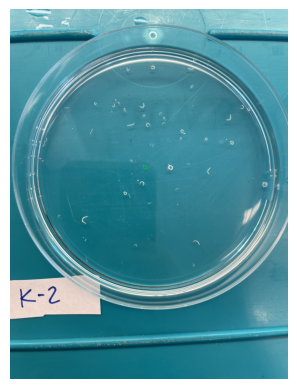

In [7]:
import cv2
import matplotlib.pyplot as plt

# Load the SAM model
model = SAM("sam2.1_b.pt")

# Display model information (optional)
model.info()

# Normalized bounding box (as given)
normalized_bboxes = [0.486844, 0.427923, 0.010982, 0.008708]  # [x_center, y_center, width, height] in normalized format

# Load the image and get its dimensions
image_path = r"D:\CODES\MyGitHub\WormCount\worm_dataset\test\images\image00004.jpeg"
image = cv2.imread(image_path)
h, w, _ = image.shape  # Get image height and width

# Extract normalized bounding box components
x_center, y_center, width, height = normalized_bboxes

# Convert normalized coordinates to pixel coordinates
x_center_pixel = x_center * w
y_center_pixel = y_center * h
width_pixel = width * w
height_pixel = height * h

# Convert to real bounding box (in pixels) [x_min, y_min, x_max, y_max]
x_min = int(x_center_pixel - (width_pixel / 2))
y_min = int(y_center_pixel - (height_pixel / 2))
x_max = int(x_center_pixel + (width_pixel / 2))
y_max = int(y_center_pixel + (height_pixel / 2))

# Prepare the real bounding box for the model (as [x_min, y_min, x_max, y_max])
real_bboxes = [x_min, y_min, x_max, y_max]
print("Real BBoxes",real_bboxes)
# Run inference with the real bounding box
results = model(image_path, bboxes=real_bboxes)

# Draw the real bounding box on the image (in pixel coordinates)
cv2.rectangle(image, (x_min, y_min), (x_max, y_max), (0, 255, 0), 2)  # Green box, thickness 2

# Convert the image from BGR (OpenCV) to RGB (matplotlib)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Display the image with the bounding box
plt.imshow(image_rgb)
plt.axis('off')  # Hide axes
plt.show()
